# Step11 — run and review notebook

This notebook is the **execution + QC + review** notebook for Step11.

It follows the same pattern as the Step09/Step10 notebooks:

1. configure paths and options  
2. run the production scripts  
3. inspect intermediate products  
4. inspect the final flux-calibrated spectra  
5. display the main QC products

## Adopted production chain

- **11a**: `step11a_extract_header_radec_resilient.py`
- **11b**: `step11b_query_skymapper.py`
- **11c**: `step11c_fluxcal_b.py`

## Adopted QC scripts

- **global grid / closeout**: `qc_step11_grid_patched_v2.py`
- **detailed per-slit summary pages**: `qc_step11_summary_b.py`

In [1]:
from pathlib import Path
import os
import subprocess
import shlex
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
from IPython.display import display, Image

#Go fishing for the config file
import sys
from pathlib import Path
# force repo root into Python path
REPO = Path().resolve().parent#s[1]   # go up from qc/step11 → repo root
sys.path.insert(0, str(REPO))
#
import config

#check
#import os
#print("CWD:", os.getcwd())
#print("REPO:", REPO)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## Configuration

Edit only this cell before running the notebook.

In [2]:
# --- repo / environment ---
REPO = Path("/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline")
PYTHON = "python"   # or full path to the environment python if needed

# --- Step10 authoritative input to Step11 ---
INFILE = Path("/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric/extract1d_optimal_ridge_all_wav_ohclean_tellcorr.fits")


# --- Step11 working directory ---
ROOT11 = Path("/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal")

# --- one representative slit for focused display ---
SLIT = "SLIT024"

# --- run controls ---
RUN_STEP11A = True
RUN_STEP11B = True
RUN_STEP11C = True
RUN_QC_GRID = True
RUN_QC_SUMMARY = True

# --- production scripts ---
STEP11A = REPO / "pipeline/step11_fluxcal/step11a_extract_header_radec_resilient.py"
STEP11B = REPO / "pipeline/step11_fluxcal/step11b_query_skymapper.py"
STEP11C = REPO / "pipeline/step11_fluxcal/step11c_fluxcal_b.py"

# --- QC scripts ---
QC_GRID = REPO / "qc/step11/qc_step11_grid_patched_v2.py"
QC_SUMMARY = REPO / "qc/step11/qc_step11_summary_b.py"

# --- derived outputs ---
RADECCSV = ROOT11 / "slit_trace_radec_all.csv"
PHOTCSV  = ROOT11 / "slit_trace_radec_skymapper_all.csv"
OUTFILE  = ROOT11 / "Extract1D_fluxcal.fits"
SUMCSV   = ROOT11 / "Step11_fluxcal_summary.csv"
QAPLOT   = ROOT11 / "Step11_fluxcal_QA.png"

QC11_DIR = ROOT11 / "qc_step11"
QC_GRID_PDF = QC11_DIR / "qc_step11_fluxcal_grid.pdf"
QC_SUMMARY_PDF = QC11_DIR / "qc_step11_summary_pages.pdf"

ROOT11.mkdir(parents=True, exist_ok=True)
QC11_DIR.mkdir(parents=True, exist_ok=True)

print("REPO   =", REPO)
print("INFILE =", INFILE, "exists =", INFILE.exists())
print("ROOT11 =", ROOT11, "exists =", ROOT11.exists())
print("SLIT   =", SLIT)

REPO   = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
INFILE = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric/extract1d_optimal_ridge_all_wav_ohclean_tellcorr.fits exists = True
ROOT11 = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal exists = True
SLIT   = SLIT024


In [3]:
def run_cmd(cmd, cwd=REPO, env=None):
    if env is None:
        env = os.environ.copy()
    env["PYTHONPATH"] = "."
    print("[CMD]", " ".join(shlex.quote(str(x)) for x in cmd))
    proc = subprocess.run(
        [str(x) for x in cmd],
        cwd=str(cwd),
        env=env,
        text=True,
        capture_output=True,
    )
    print("--- STDOUT ---")
    print(proc.stdout if proc.stdout.strip() else "[empty]")
    print("--- STDERR ---")
    print(proc.stderr if proc.stderr.strip() else "[empty]")
    if proc.returncode != 0:
        raise RuntimeError(f"Command failed with return code {proc.returncode}")
    return proc

def read_slit_table(fits_path, slit):
    with fits.open(fits_path) as hdul:
        return Table(hdul[slit].data)

def arr(tab, col):
    x = np.asarray(tab[col], float)
    if np.ma.isMaskedArray(x):
        x = x.filled(np.nan)
    return np.ravel(x)

def finite_ylim(*arrays, qlo=0.5, qhi=99.5, pad=0.08):
    vals = []
    for a in arrays:
        a = np.asarray(a, float)
        m = np.isfinite(a)
        if np.any(m):
            vals.append(a[m])
    if not vals:
        return (-1, 1)
    x = np.concatenate(vals)
    lo, hi = np.nanpercentile(x, [qlo, qhi])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return (-1, 1)
    d = hi - lo
    return lo - pad * d, hi + pad * d

## Inventory before running

In [4]:
for p in [STEP11A, STEP11B, STEP11C, QC_GRID, QC_SUMMARY, INFILE, ROOT11]:
    print(p, "->", p.exists())

/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step11_fluxcal/step11a_extract_header_radec_resilient.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step11_fluxcal/step11b_query_skymapper.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step11_fluxcal/step11c_fluxcal_b.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step11/qc_step11_grid_patched_v2.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step11/qc_step11_summary_b.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/M

## Execute Step11

In [5]:
if RUN_STEP11A:
    run_cmd([
        PYTHON,
        STEP11A,
        "--infile", INFILE,
        "--out", RADECCSV,
    ])
else:
    print("RUN_STEP11A = False  -> skipped")

[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step11_fluxcal/step11a_extract_header_radec_resilient.py' --infile '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric/extract1d_optimal_ridge_all_wav_ohclean_tellcorr.fits' --out '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/slit_trace_radec_all.csv'
--- STDOUT ---
[OK] Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/slit_trace_radec_all.csv
Rows kept: 62 / 62
Recovered from headers : 60
Recovered from geometry: 2
Recovered from CSV     : 0


In [6]:
if RUN_STEP11B:
    run_cmd([
        PYTHON,
        STEP11B,
        "--in", RADECCSV,
        "--out", PHOTCSV,
    ])
else:
    print("RUN_STEP11B = False  -> skipped")

[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step11_fluxcal/step11b_query_skymapper.py' --in '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/slit_trace_radec_all.csv' --out '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/slit_trace_radec_skymapper_all.csv'
--- STDOUT ---
1/62  SLIT000  RA=101.24566 DEC=0.22508  r=16.0311  sep=0.2650151510878041
2/62  SLIT001  RA=101.24674 DEC=0.22632  r=16.4873  sep=0.1385741380803318
3/62  SLIT002  RA=101.24744 DEC=0.22538  r=nan  sep=nan
4/62  SLIT003  RA=101.24847 DEC=0.21070  r=16.907  sep=0.0796954466129423
5/62  SLIT004  RA=101.24902 DEC=0.23451  r=19.3205  sep=0.8130494918816572

In [7]:
if RUN_STEP11C:
    run_cmd([
        PYTHON,
        STEP11C,
        INFILE,
        PHOTCSV,
        "--out-fits", OUTFILE,
        "--out-summary", SUMCSV,
        "--qa-plot", QAPLOT,
    ])
else:
    print("RUN_STEP11C = False  -> skipped")

[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step11_fluxcal/step11c_fluxcal_b.py' '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric/extract1d_optimal_ridge_all_wav_ohclean_tellcorr.fits' '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/slit_trace_radec_skymapper_all.csv' --out-fits '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/Extract1D_fluxcal.fits' --out-summary '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_S

In [8]:
if RUN_QC_GRID:
    run_cmd([
        PYTHON,
        QC_GRID,
    ])
    if QC_GRID_PDF.exists():
        print("Wrote:", QC_GRID_PDF)
else:
    print("RUN_QC_GRID = False  -> skipped")

[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step11/qc_step11_grid_patched_v2.py'
--- STDOUT ---
[DONE] Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/qc_step11_fluxcal_grid.pdf

--- STDERR ---
[empty]
Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/qc_step11_fluxcal_grid.pdf


In [9]:
if RUN_QC_SUMMARY:
    run_cmd([
        PYTHON,
        QC_SUMMARY,
    ])
    if QC_SUMMARY_PDF.exists():
        print("Wrote:", QC_SUMMARY_PDF)
else:
    print("RUN_QC_SUMMARY = False  -> skipped")

[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step11/qc_step11_summary_b.py'
--- STDOUT ---
[DONE] Wrote /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/qc_step11_summary_pages.pdf

--- STDERR ---
[empty]
Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/qc_step11_summary_pages.pdf


## Inventory after running

In [10]:
for p in [RADECCSV, PHOTCSV, OUTFILE, SUMCSV, QAPLOT, QC_GRID_PDF, QC_SUMMARY_PDF]:
    print(p.name, "->", p.exists())

slit_trace_radec_all.csv -> True
slit_trace_radec_skymapper_all.csv -> True
Extract1D_fluxcal.fits -> True
Step11_fluxcal_summary.csv -> True
Step11_fluxcal_QA.png -> True
qc_step11_fluxcal_grid.pdf -> True
qc_step11_summary_pages.pdf -> True


## Step11a output — slit coordinates

In [11]:
if RADECCSV.exists():
    df_radec = pd.read_csv(RADECCSV)
    display(df_radec.head())
    print("Rows:", len(df_radec))
    if "SRC" in df_radec.columns:
        print(df_radec["SRC"].value_counts(dropna=False))
else:
    df_radec = None
    print("Missing:", RADECCSV)

,slit,SLITNUM,RA,DEC,x_center,xlo,xhi,YMIN,SRC
0,SLIT000,0,101.245660,0.225081,2627.461703,2619.0,2636.0,0.0,HEADER
1,SLIT001,1,101.246742,0.226315,2642.888492,2635.0,2652.0,11.0,HEADER
2,SLIT002,2,101.247444,0.225376,2560.205023,2552.0,2569.0,18.0,HEADER
3,SLIT003,3,101.248469,0.210702,2609.913048,2602.0,2619.0,0.0,HEADER
4,SLIT004,4,101.249022,0.234507,2530.789124,2523.0,2540.0,0.0,HEADER


Rows: 62
SRC
HEADER      60
GEOMETRY     2
Name: count, dtype: int64


## Step11b output — SkyMapper matches

In [12]:
if PHOTCSV.exists():
    df_phot = pd.read_csv(PHOTCSV)
    display(df_phot.head())
    print("Rows:", len(df_phot))
else:
    df_phot = None
    print("Missing:", PHOTCSV)

,slit,SLITNUM,RA,DEC,x_center,xlo,xhi,YMIN,SRC,r_mag,r_err,i_mag,i_err,z_mag,z_err,match_sep_arcsec
0,SLIT000,0,101.245660,0.225081,2627.461703,2619.0,2636.0,0.0,HEADER,16.0311,0.0070,15.6410,0.0064,15.4116,0.0066,0.265015
1,SLIT001,1,101.246742,0.226315,2642.888492,2635.0,2652.0,11.0,HEADER,16.4873,0.0085,16.2146,0.0081,16.0551,0.0090,0.138574
2,SLIT002,2,101.247444,0.225376,2560.205023,2552.0,2569.0,18.0,HEADER,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SLIT003,3,101.248469,0.210702,2609.913048,2602.0,2619.0,0.0,HEADER,16.9070,0.0068,16.4649,0.0074,16.2164,0.0082,0.079695
4,SLIT004,4,101.249022,0.234507,2530.789124,2523.0,2540.0,0.0,HEADER,19.3205,0.0179,18.6938,0.0364,18.3077,0.0519,0.813049


Rows: 62


## Step11c output — flux-calibrated MEF

In [13]:
if OUTFILE.exists():
    with fits.open(OUTFILE) as h:
        print("N HDU =", len(h))
        print("First slit =", h[1].name)
        print("Last slit  =", h[-1].name)
        print()
        print("Columns in first slit:")
        print(h[1].data.names)
else:
    print("Missing:", OUTFILE)

N HDU = 63
First slit = SLIT000
Last slit  = SLIT062

Columns in first slit:
['YPIX', 'FLUX', 'VAR', 'SKY', 'OBJ_PRESKY', 'X0', 'NOBJ', 'NSKY', 'SKYSIG', 'APLOSS_FRAC', 'FLUX_APCORR', 'VAR_APCORR', 'EDGEFLAG', 'TRXLEFT', 'TRXRIGHT', 'LAMBDA_NM', 'OH_SHIFT_NM', 'CONTINUUM_P1', 'RESID_P1', 'CONT1', 'RESID1', 'LINE1', 'SIGNAL_CLEAN1', 'CONT2', 'RESID2', 'OH_MODEL_P1', 'STELLAR_P1', 'RESID_POSTOH_P1', 'OH_MODEL', 'STELLAR', 'RESID_POSTOH', 'CONTINUUM_STEP09', 'STEP09_PREF', 'FLUX_TELLCOR_O2', 'VAR_TELLCOR_O2', 'FLUX_FLAM', 'VAR_FLAM2']


In [14]:
if SUMCSV.exists():
    df_sum = pd.read_csv(SUMCSV)
    display(df_sum.head())
    print("Rows:", len(df_sum))
    if "cal_mode" in df_sum.columns:
        print(df_sum["cal_mode"].value_counts(dropna=False))
else:
    df_sum = None
    print("Missing:", SUMCSV)

,slit,cal_mode,qcflag,nband,S,alpha,S_r,S_i,S_z,C_r,...,F_i,F_z,dm_r,dm_i,dm_z,m_r_ab,m_i_ab,m_z_ab,mag_system_used,flux_input_col
0,SLIT000,GRAY,DISP>0.20,3,2.078629e-15,NaN,4.565897e-15,1.968478e-15,2.078629e-15,0.239937,...,1.072320e-15,9.843928e-16,0.854373,-0.059116,0.000000e+00,16.0311,15.6410,15.4116,ab,FLUX_TELLCOR_O2
1,SLIT001,GRAY,DISP>0.20,3,1.584681e-14,NaN,5.537457e-14,1.584681e-14,9.160910e-15,0.012997,...,6.322436e-16,5.442124e-16,1.358421,0.000000,-5.950079e-01,16.4873,16.2146,16.0551,ab,FLUX_TELLCOR_O2
2,SLIT002,NONE,NOMAG,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ab,FLUX_TELLCOR_O2
3,SLIT003,GRAY,OK,3,1.356389e-15,NaN,1.545955e-15,9.633323e-16,1.356389e-15,0.316276,...,5.020702e-16,4.690817e-16,0.142032,-0.371521,0.000000e+00,16.9070,16.4649,16.2164,ab,FLUX_TELLCOR_O2
4,SLIT004,GRAY,OK,3,3.769060e-16,NaN,4.065904e-16,2.909727e-16,3.769060e-16,0.130229,...,6.444726e-17,6.834841e-17,0.082310,-0.280952,3.552714e-15,19.3205,18.6938,18.3077,ab,FLUX_TELLCOR_O2


Rows: 62
cal_mode
GRAY    49
NONE    13
Name: count, dtype: int64


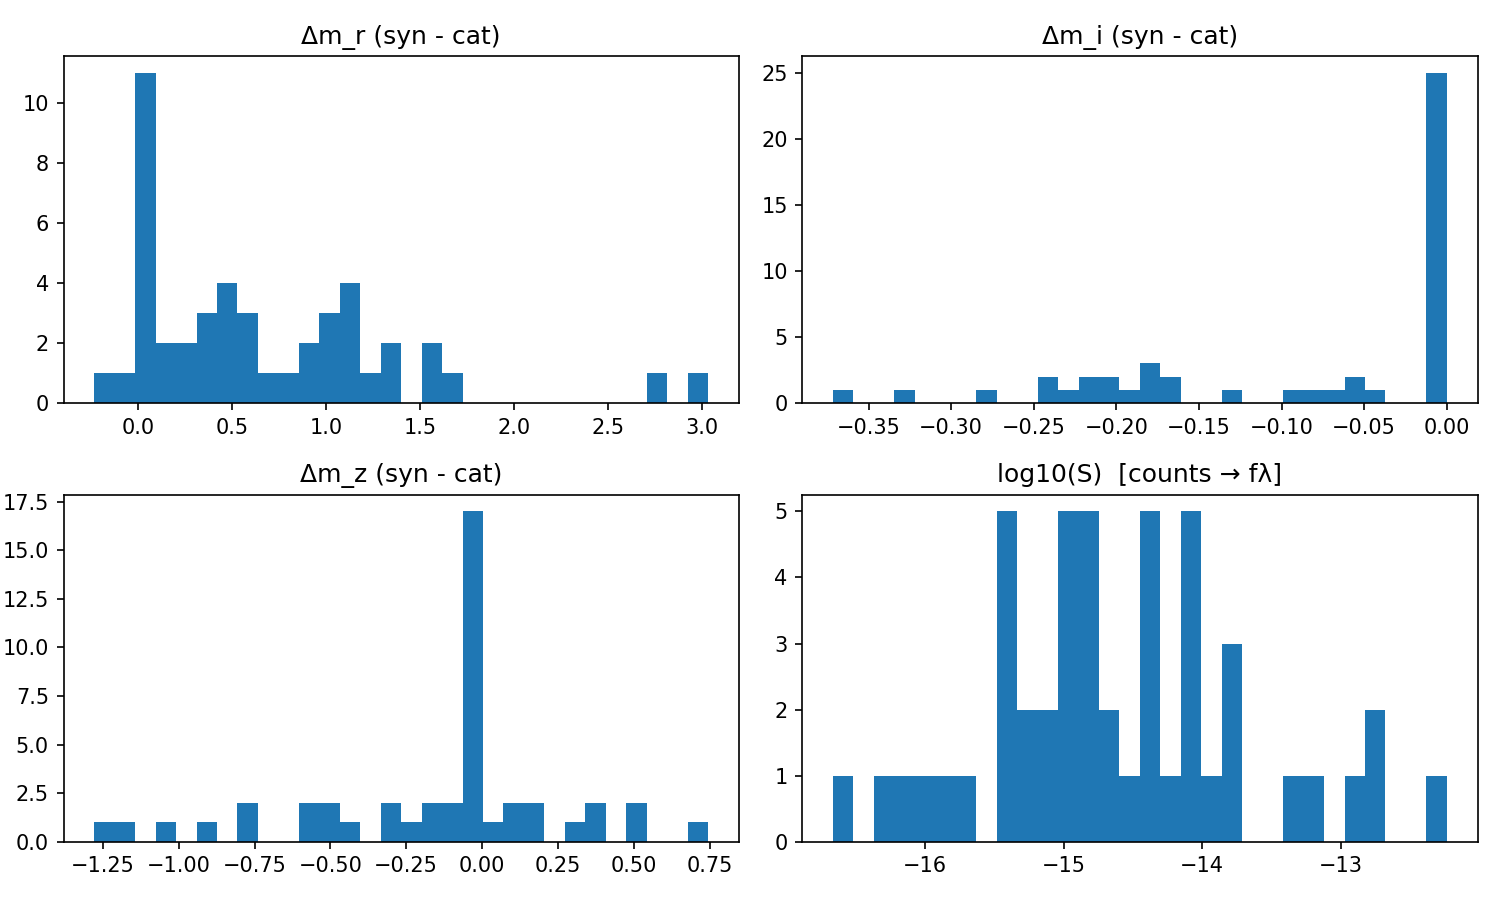

In [15]:
if QAPLOT.exists():
    display(Image(filename=QAPLOT))
else:
    print("Missing:", QAPLOT)

## Representative slit inspection

In [16]:
if OUTFILE.exists():
    tin = read_slit_table(INFILE, SLIT)
    tout = read_slit_table(OUTFILE, SLIT)

    lam_in = arr(tin, "LAMBDA_NM")
    flux_in_col = "FLUX_TELLCOR_O2" if "FLUX_TELLCOR_O2" in tin.colnames else ("STELLAR" if "STELLAR" in tin.colnames else "FLUX")
    flux_out_col = "FLUX_FLAM" if "FLUX_FLAM" in tout.colnames else ("FLUX_TELLCOR_O2" if "FLUX_TELLCOR_O2" in tout.colnames else None)

    flux_in = arr(tin, flux_in_col) if flux_in_col else None
    flux_out = arr(tout, flux_out_col) if flux_out_col else None

    hdr = fits.getheader(OUTFILE, SLIT)
    for k in ["CALMODE", "CALSCALE", "CALALPHA", "DM_R", "DM_I", "DM_Z"]:
        if k in hdr:
            print(k, "=", hdr[k])
else:
    print("Missing:", OUTFILE)

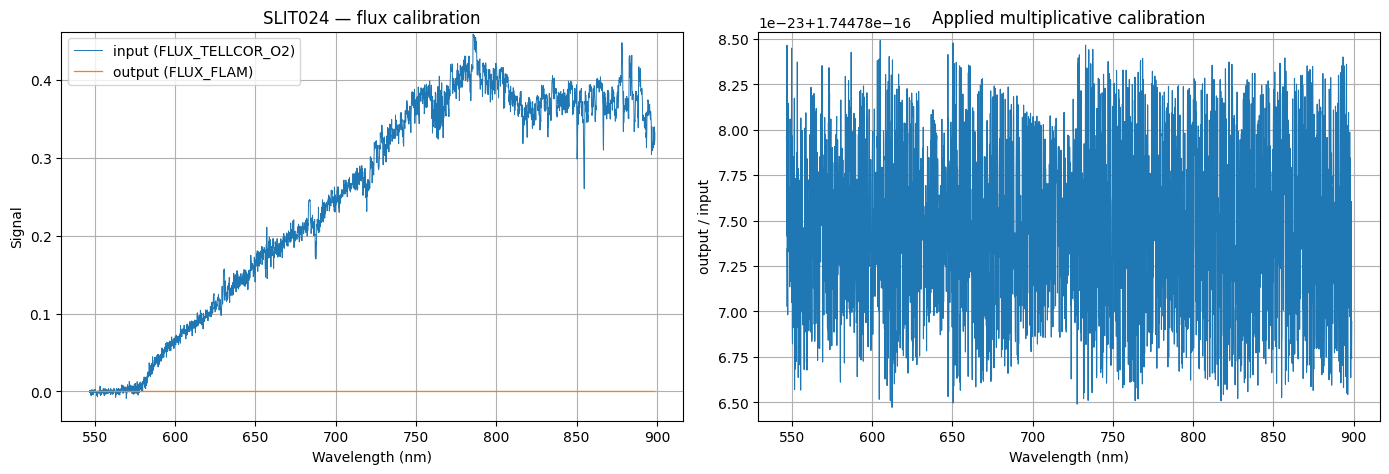

In [17]:
if OUTFILE.exists() and flux_in is not None and flux_out is not None:
    fig = plt.figure(figsize=(14, 5))

    ax = fig.add_subplot(121)
    ax.plot(lam_in, flux_in, lw=0.7, label=f"input ({flux_in_col})")
    ax.plot(lam_in, flux_out, lw=0.9, label=f"output ({flux_out_col})")
    ax.set_title(f"{SLIT} — flux calibration")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Signal")
    ax.set_ylim(*finite_ylim(flux_in, flux_out))
    ax.legend()

    ax = fig.add_subplot(122)
    ratio = np.full_like(flux_out, np.nan, dtype=float)
    m = np.isfinite(flux_in) & np.isfinite(flux_out) & (np.abs(flux_in) > 0)
    ratio[m] = flux_out[m] / flux_in[m]
    ax.plot(lam_in, ratio, lw=0.8)
    ax.axhline(1.0, lw=0.8, ls="--", color="0.5")
    ax.set_title("Applied multiplicative calibration")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("output / input")
    ax.set_ylim(*finite_ylim(ratio))

    plt.tight_layout()
    plt.show()

Number of slits: 49


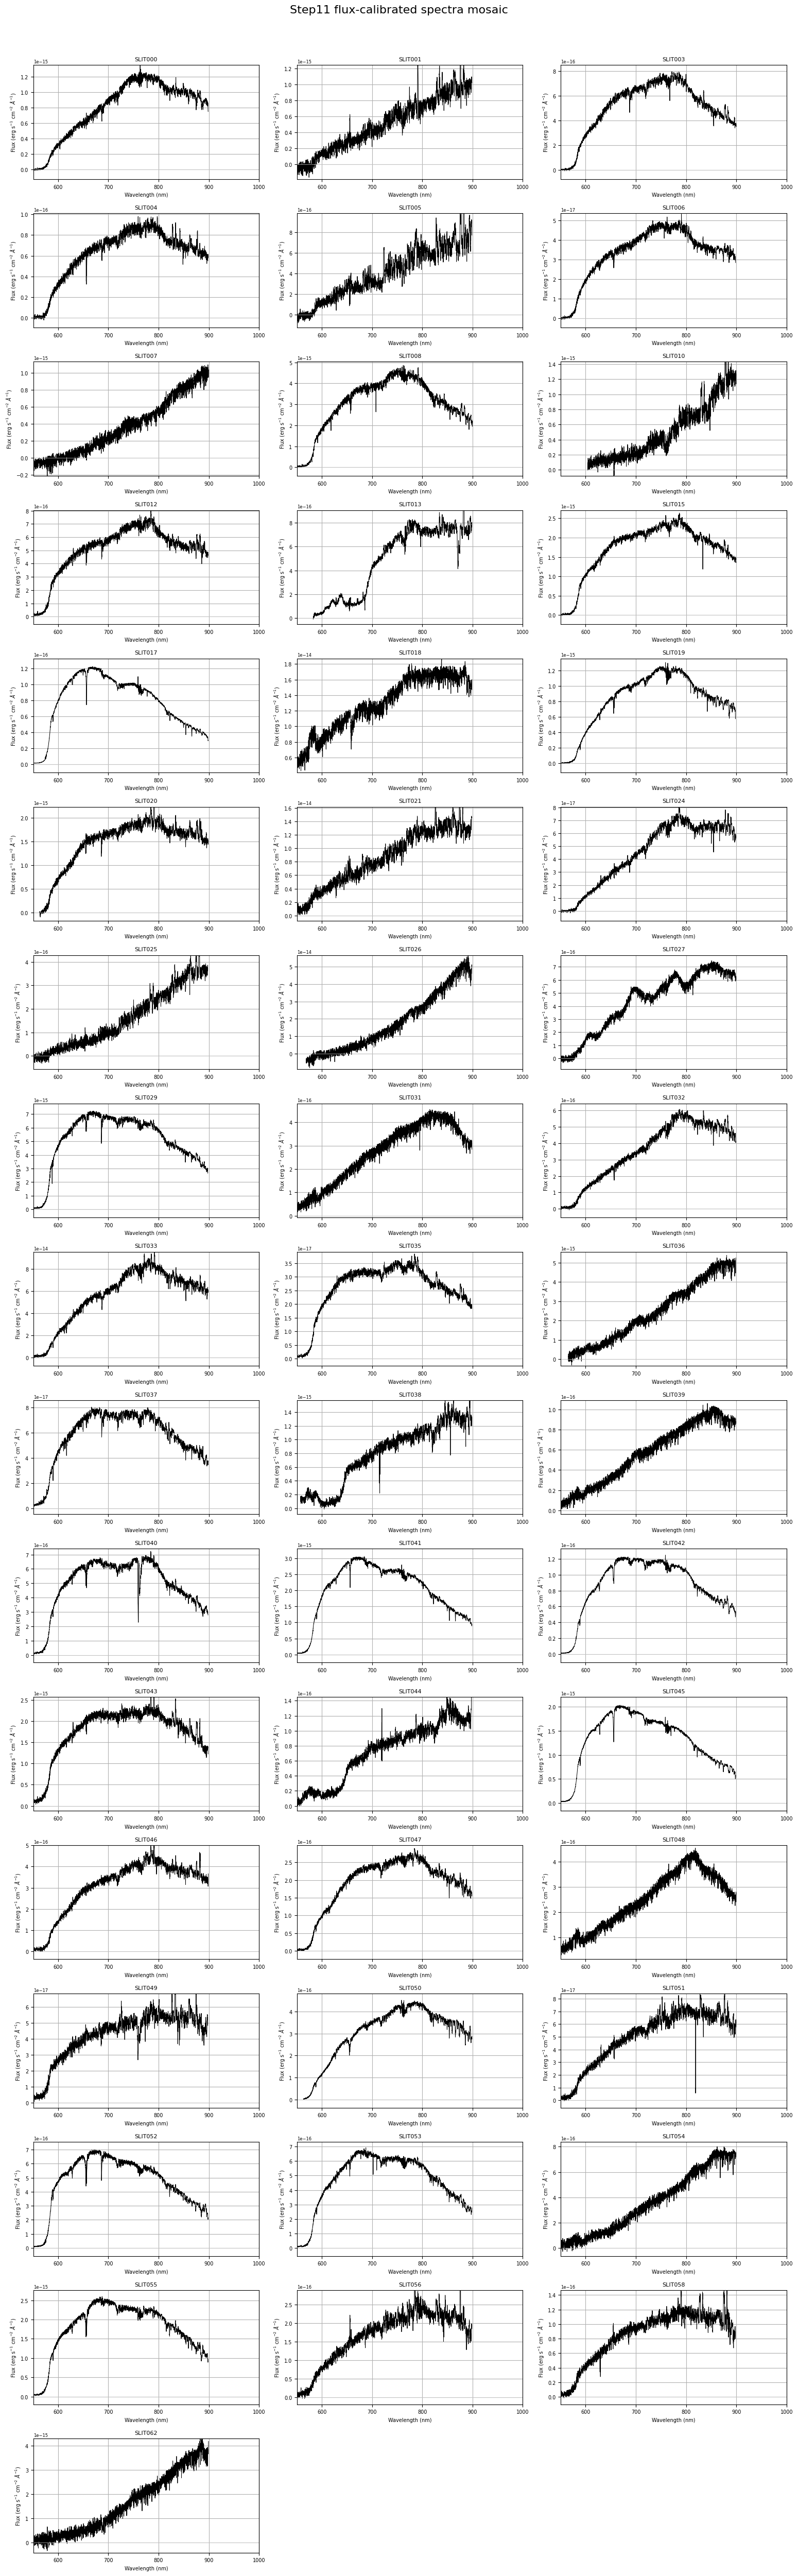

Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/all_fluxcal_mosaic_fullaxes.png


In [18]:
import math
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

FITS_IN = OUTFILE
OUTPNG = ROOT11 / "qc_step11" / "all_fluxcal_mosaic_fullaxes.png"

def slit_num(name):
    try:
        return int(str(name).replace("SLIT", ""))
    except Exception:
        return 9999

def robust_ylim(y, qlo=2, qhi=98, pad=0.10):
    y = np.asarray(y, float)
    y = y[np.isfinite(y)]
    if y.size < 5:
        return (-1, 1)
    lo, hi = np.nanpercentile(y, [qlo, qhi])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        med = np.nanmedian(y)
        sig = np.nanstd(y)
        if not np.isfinite(sig) or sig <= 0:
            sig = 1.0
        return med - 2 * sig, med + 2 * sig
    d = hi - lo
    return lo - pad * d, hi + pad * d

slit_data = {}

with fits.open(FITS_IN) as hdul:
    for hdu in hdul[1:]:
        name = hdu.name.strip().upper()
        if not name.startswith("SLIT"):
            continue
        d = hdu.data
        if d is None:
            continue

        cols = [c.upper() for c in d.names]
        if "LAMBDA_NM" not in cols:
            continue

        if "FLUX_FLAM" in cols:
            ycol = "FLUX_FLAM"
        elif "FLUX_TELLCOR_O2" in cols:
            ycol = "FLUX_TELLCOR_O2"
        elif "FLUX" in cols:
            ycol = "FLUX"
        else:
            continue

        lam = np.asarray(d["LAMBDA_NM"], float)
        flux = np.asarray(d[ycol], float)

        m = np.isfinite(lam) & np.isfinite(flux)
        if np.any(m):
            slit_data[name] = (lam[m], flux[m], ycol)

slits = sorted(slit_data.keys(), key=slit_num)
print("Number of slits:", len(slits))

all_lam = np.concatenate([slit_data[s][0] for s in slits])
x_lo = np.nanpercentile(all_lam, 1)
x_hi = 950.0

ncols = 3
nrows = math.ceil(len(slits) / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(5.2 * ncols, 3.0 * nrows),
    sharex=False,
    sharey=False
)

axes = np.atleast_1d(axes).ravel()

xticks = np.arange(600, 1001, 100)

for ax in axes:
    ax.set_visible(False)

for ax, slit in zip(axes, slits):
    ax.set_visible(True)
    lam, flux, ycol = slit_data[slit]

    ax.plot(lam, flux, color="k", lw=0.7)
    ax.axhline(0.0, color="0.8", lw=0.5)

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(*robust_ylim(flux))

    # ticks
    ax.set_xticks(xticks)
    ax.tick_params(axis="both", labelsize=7)

    # FORCE scientific notation on Y
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_size(6)

    # labels WITH UNITS on EVERY subplot
    ax.set_xlabel("Wavelength (nm)", fontsize=7)
    ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)", fontsize=7)

    ax.set_title(slit, fontsize=8)

fig.suptitle("Step11 flux-calibrated spectra mosaic", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])

fig.savefig(OUTPNG, dpi=180, bbox_inches="tight")
plt.show()

print("Wrote:", OUTPNG)

In [19]:
SISI_IMAGE_FITS = REPO / "calibration" / "sisi" / "Coadd_i_median_078-082_ff_flipx_wcs_manual.fits"
print(SISI_IMAGE_FITS)
print(SISI_IMAGE_FITS.exists())

/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/calibration/sisi/Coadd_i_median_078-082_ff_flipx_wcs_manual.fits
True


In [29]:
QC_SUMMARY = REPO / "qc/step11/qc_step11_summary.py"
QC_SUMMARY_PDF = ROOT11 / "qc_step11" / "qc_step11_summary_pages.pdf"

TRACECOORDS_PAIR = f"{config.SCI_EVEN_TRACECOORDS}|{config.SCI_ODD_TRACECOORDS}"
GEOMETRY_PAIR = f"{config.EVEN_TRACES_GEOM}|{config.ODD_TRACES_GEOM}"

cmd = [
    PYTHON,
    QC_SUMMARY,
    "--extract", OUTFILE,
    "--photcat", config.STEP11_PHOTCAT,
    "--image", config.SISI_IMAGE_FITS,
    "--detector", config.FINAL_SCIENCE,
    "--tracecoords", TRACECOORDS_PAIR,
    "--geometry", GEOMETRY_PAIR,
    "--outpdf", QC_SUMMARY_PDF,
]

run_cmd(cmd)


print("Check output summary")
from IPython.display import FileLink, display
display(FileLink(str(QC_SUMMARY_PDF.resolve())))



[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step11/qc_step11_summary.py' --extract '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/Extract1D_fluxcal.fits' --photcat '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/slit_trace_radec_skymapper_all.csv' --image '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/calibration/sisi/Coadd_i_median_078-082_ff_flipx_wcs_manual.fits' --detector '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/r

/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/qc_step11_summary_pages.pdf

## QC products

In [21]:
for p in [QC_GRID_PDF, QC_SUMMARY_PDF]:
    print(p.name, "->", p.exists())

qc_step11_fluxcal_grid.pdf -> True
qc_step11_summary_pages.pdf -> True


## Handoff / final product

The final pipeline product is:

`Extract1D_fluxcal.fits`

Key output columns include:

- `FLUX_FLAM`
- `VAR_FLAM2` (when variance is available)

The main auxiliary products are:

- `slit_trace_radec_all.csv`
- `slit_trace_radec_skymapper_all.csv`
- `Step11_fluxcal_summary.csv`
- `Step11_fluxcal_QA.png`